In [28]:
import canopus
import qiskit
import numpy as np
from qiskit.circuit.random import random_circuit
from qiskit.transpiler import PassManager

### CanopusMapping vs. SabreMapping

In [17]:
# Input circuit represented in logical-level gate sequence
qc = random_circuit(10, 100, max_operands=2)
canopus.utils.print_circ_info(qc)
qc.draw(fold=-1)

+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     10     |    769    |     225      |  100  |    82    |
+------------+-----------+--------------+-------+----------+


┌──────────────────────────┐     ┌───┐                                                                        ┌──────┐┌────────────┐┌────────────┐                                                                        ┌──────────────────────────┐┌─────────────────────────┐              ┌───────────────┐                                  ┌──────────────────────────┐        ┌────────────┐                    ┌──────┐                                                                                                                                                                             ┌────┐          ┌──────────────────┐              ┌─────┐          ┌─────────────────────────┐     ┌───┐                                                                                                                                                             ┌───┐               ┌────────────┐                                                                     ┌───┐                     ┌───────────────────────────┐          ┌────────────┐                                  ┌────────────┐     ┌───┐                ┌───┐               ┌────────────────────┐       ┌────────────┐              ┌─────┐                                                                                                                                                                                                                                     ┌───┐                                            ┌───┐                                                                                            ┌────────────┐           ┌───┐          ┌────────────────────┐                                                                                                                                                   ┌───┐         ┌───┐     ┌────────────┐                                                            ┌───┐                                               ┌───────────────────┐┌───────────────────┐                                                                                                    ┌────┐                       ┌──────────────┐           ┌───┐                         ┌─────┐                        ┌───┐           ┌──────────────────────────┐                                                                                                              ┌──────────────┐┌─────────────────────────┐       ┌─────────────┐                                                                   ┌─────┐                                                                                                 ┌────────────────────┐               ┌────────────────────────┐                                                       ┌───┐               ┌───┐            ┌────────────┐                                                                                                     ┌──────────────┐┌─────────────────────────┐            ┌────┐                                                                                                                                                              ┌────────────┐┌──────────────────┐   ┌─────┐                                                                               ┌───┐           ┌───┐                                              ┌───┐                ┌────┐                     ┌─────┐                 ┌────────────┐                  ┌───┐                                                                                               ┌─────────────────────────┐    ┌───┐                                                                                            ┌───────────────────────────┐    ┌───┐                    ┌──────────────┐                           ┌──────┐         ┌──────┐         ┌──────────────────────────┐                                                                                                                  ┌───┐         ┌──────┐       ┌───┐                                                                                                         

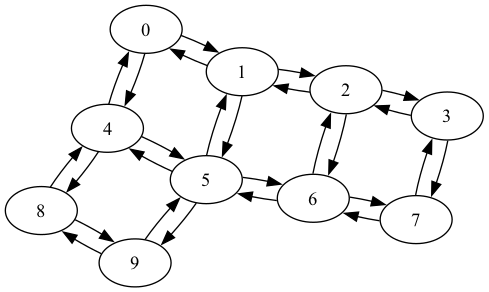

In [18]:
# Coupling graph (Qiskit CouplingGraph instance) representing the target quantum hardware physical-qubit connectivity
coupling_graph = canopus.utils.gene_square_coupling_map(qc.num_qubits)
coupling_graph.draw()

In [ ]:
######### Canopus mapping/routing workflow #########


# 1. define backend
backend = canopus.CanopusBackend(
    coupling_map=coupling_graph,
    isa_type='cx', # Optional: 'cx', 'sqisw', 'zzphase', 'het', ...
)

# 2. define CanopusMapping instance (qiskit.transpiler.Transformation instance) and wrap it into a qiskit.transpiler.PassManager
pm = PassManager(canopus.CanopusMapping(backend))


# 3. rebase the input circuit into {Can, U3} ISA (with logical-level optimization) by PyTKet or Qiskit
qc = canopus.rebase_to_tk2(qc)
qc = canopus.rebase_to_canonical(qc)

# 3. run the PassManager on the input circuit to obtain the mapped/routed circuit
qc_mapped = pm.run(qc)

In [40]:
print('Gate stats:', qc_mapped.count_ops())
canopus.utils.print_circ_info(qc_mapped, 'Canopus Mapping')

Gate stats: OrderedDict({'u': 414, 'can': 202, 'swap': 152})
+----------------------------------------------------------+
|                     Canopus Mapping                      |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     10     |    768    |     354      |  278  |   179    |
+------------+-----------+--------------+-------+----------+


In [ ]:
qiskit.transpile(qc_mapped, basis_gates=['cx', 'u'])

In [ ]:
# In comparison with SabreMapping
qc_mapped_sabre = PassManager(canopus.SabreMapping(backend)).run(qc)
print('Gate stats:', qc_mapped_sabre.count_ops())
canopus.utils.print_circ_info(qc_mapped_sabre, 'Sabre Mapping')

Gate stats: OrderedDict({'u': 414, 'can': 202, 'swap': 120})
+----------------------------------------------------------+
|                      Sabre Mapping                       |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     10     |    736    |     322      |  266  |   169    |
+------------+-----------+--------------+-------+----------+


In [32]:
# ! NOTE: Although Canopus induces more SWAP gates, the actual circuit cost is lower when the circuit is supposed to be synthesized in {CX, U3}
print('[CanopusMapping] Count-cost and Depth-cost:', backend.cost_estimator.eval_circuit_cost(qc_mapped))
print('[SabreMapping] Count-cost and Depth-cost:', backend.cost_estimator.eval_circuit_cost(qc_mapped_sabre))

[CanopusMapping] Count-cost and Depth-cost: (676.0, 339.0)
[SabreMapping] Count-cost and Depth-cost: (692.0, 377.0)


In [39]:
canopus.utils.print_circ_info(qc, 'aaa')

+----------------------------------------------------------+
|                           aaa                            |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     10     |    616    |     202      |  157  |    78    |
+------------+-----------+--------------+-------+----------+
